# Прогнозирование оттока клиентов банка с использованием логистической регрессии

Цель проекта — разработка модели логистической регрессии для прогнозирования оттока клиентов банка и исследование влияния различных настроек модели (регуляризации, балансировки классов и порога классификации) на её качество.

**Признаки**
- RowNumber — индекс строки в данных
- CustomerId — уникальный идентификатор клиента
- Surname — фамилия
- CreditScore — кредитный рейтинг
- Geography — страна проживания
- Gender — пол
- Age — возраст
- Tenure — сколько лет человек является клиентом банка
- Balance — баланс на счёте
- NumOfProducts — количество продуктов банка, используемых клиентом
- HasCrCard — наличие кредитной карты
- IsActiveMember — активность клиента
- EstimatedSalary — предполагаемая зарплата

**Целевой признак**
- Exited — факт ухода клиента

In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [ ]:
df = pd.read_csv('Churn.csv')

## 1. EDA

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [ ]:
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"], axis=1)

In [ ]:
def to_snake_case(columns):
    new_cols = []
    for col in columns:
        col = re.sub(r'(?<!^)(?=[A-Z])', '_', col)
        col = col.lower()
        new_cols.append(col)
    return new_cols

df.columns = to_snake_case(df.columns)

In [ ]:
print(df.columns.tolist())

['credit_score', 'geography', 'gender', 'age', 'tenure', 'balance', 'num_of_products', 'has_cr_card', 'is_active_member', 'estimated_salary', 'exited']


Сразу ислючим признаки, не обладающие предсказательной ценностью (row_number, customer_id, surname), поскольку они являются либо техническими, либо уникальными идентификаторами.

А также, названия признаков были приведены к единому стилю snake_case, что обеспечивает консистентность именования, снижает вероятность ошибок при обращении к столбцам и улучшает читаемость кода.

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      10000 non-null  int64  
 1   geography         10000 non-null  object 
 2   gender            10000 non-null  object 
 3   age               10000 non-null  int64  
 4   tenure            9091 non-null   float64
 5   balance           10000 non-null  float64
 6   num_of_products   10000 non-null  int64  
 7   has_cr_card       10000 non-null  int64  
 8   is_active_member  10000 non-null  int64  
 9   estimated_salary  10000 non-null  float64
 10  exited            10000 non-null  int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 859.5+ KB


,credit_score,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited
count,10000.000000,10000.000000,9091.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,4.997690,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.894723,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,2.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.isna().sum()

,0
credit_score,0
geography,0
gender,0
age,0
tenure,909
balance,0
num_of_products,0
has_cr_card,0
is_active_member,0
estimated_salary,0


In [ ]:
df["tenure"] = df["tenure"].fillna(df["tenure"].median())

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print("Баланс целевой переменной:\n", df['exited'].value_counts(normalize=True).rename({0:'stay',1:'exited'}))

Баланс целевой переменной:
 exited
stay      0.7963
exited    0.2037
Name: proportion, dtype: float64


Визуализация

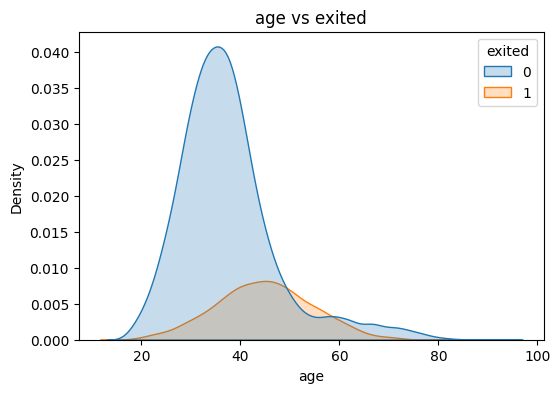

In [ ]:
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df, x="age", hue="exited", fill=True)
plt.title("age vs exited")
plt.show()

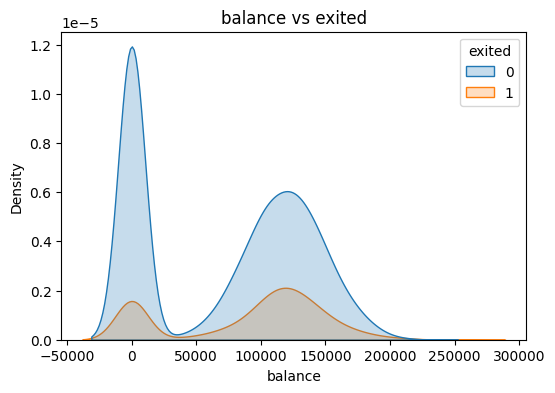

In [ ]:
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df, x="balance", hue="exited", fill=True)
plt.title("balance vs exited")
plt.show()

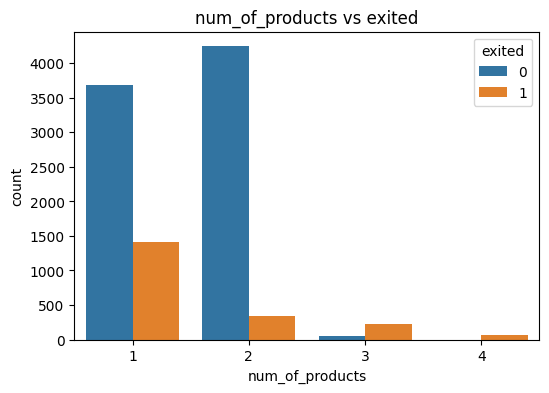

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="num_of_products", hue="exited")
plt.title("num_of_products vs exited")
plt.show()

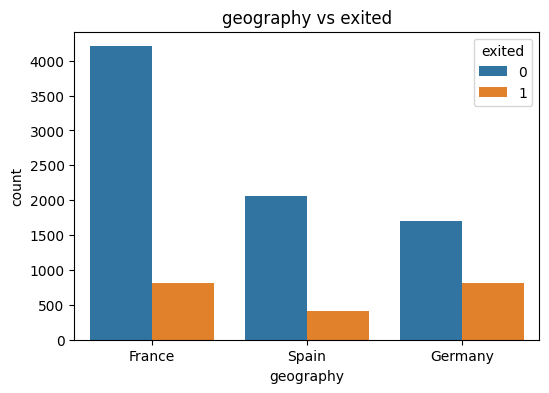

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="geography", hue="exited")
plt.title("geography vs exited")
plt.show()

In [ ]:
pd.crosstab(df['geography'], df['exited'], normalize='index')

exited,0,1
geography,,
France,0.838452,0.161548
Germany,0.675568,0.324432
Spain,0.833266,0.166734


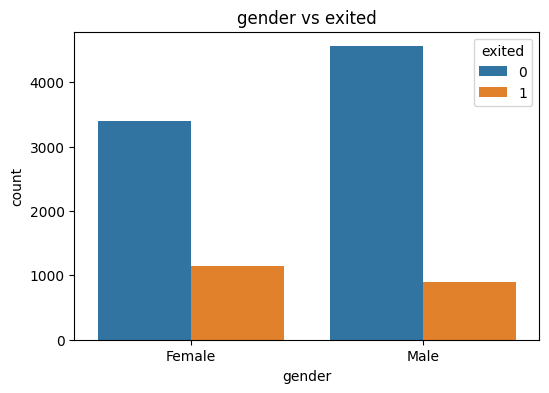

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="gender", hue="exited")
plt.title("gender vs exited")
plt.show()

In [ ]:
pd.crosstab(df['gender'], df['exited'], normalize='index')

exited,0,1
gender,,
Female,0.749285,0.250715
Male,0.835441,0.164559


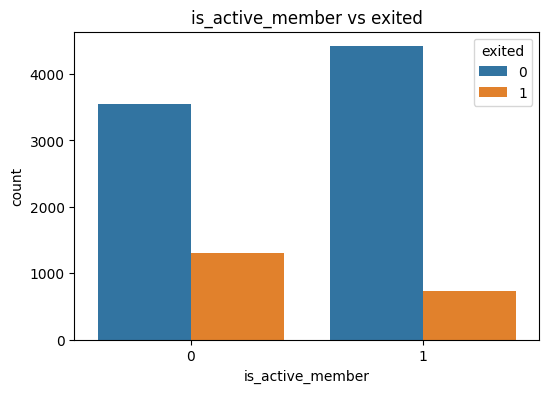

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_active_member", hue="exited")
plt.title("is_active_member vs exited")
plt.show()

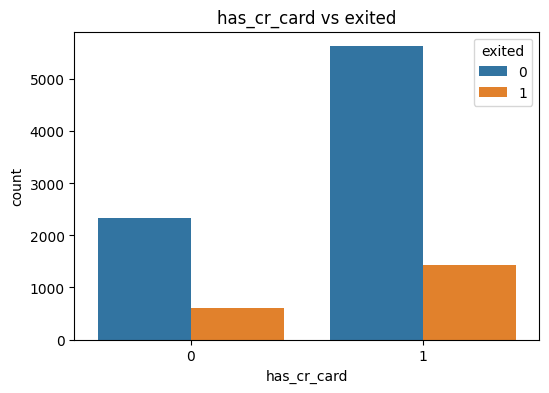

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="has_cr_card", hue="exited")
plt.title("has_cr_card vs exited")
plt.show()

In [ ]:
pd.crosstab(df['has_cr_card'], df['exited'], normalize='index')

exited,0,1
has_cr_card,,
0,0.791851,0.208149
1,0.798157,0.201843


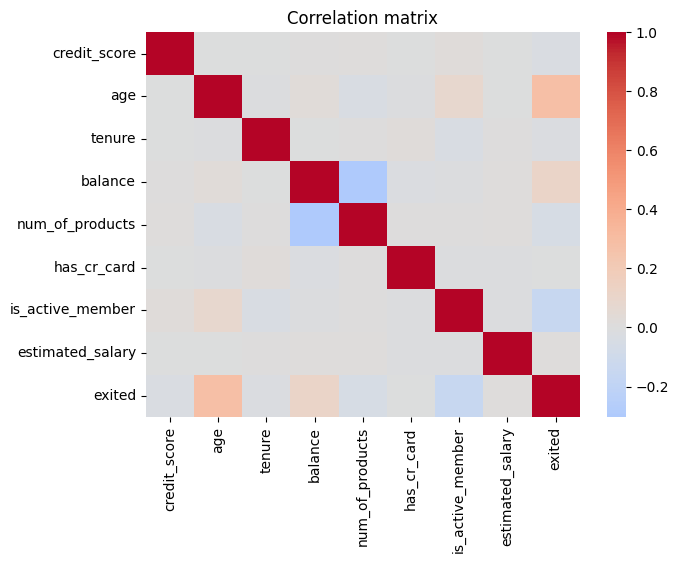

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

### Итог EDA

В ходе разведочного анализа данных были выявлены ключевые особенности распределения признаков и их связи с целевой переменной.

**Общие наблюдения:**
- В данных присутствует умеренный дисбаланс классов: доля ушедших клиентов составляет около 20%.
- Пропуски обнаружены только в признаке tenure и были заполнены медианным значением.
- Дубликаты в данных отсутствуют.

**Наиболее значимые признаки:**
- age - с увеличением возраста клиента вероятность ухода возрастает;
- is_active_member - один из самых сильных признаков: неактивные клиенты значительно чаще покидают банк;
- geography - наибольшая доля оттока наблюдается среди клиентов из Германии (32%), что существенно выше, чем во Франции и Испании (16–17%);
- gender - среди женщин доля оттока (25%) выше, чем среди мужчин (16%), что указывает на наличие связи признака с целевой переменной.

**Признаки со сложной или нелинейной зависимостью:**
- num_of_products - наблюдается нелинейная зависимость: клиенты с 2 продуктами наиболее стабильны, тогда как при 1 и более чем 2 продуктах вероятность ухода выше;
- balance - распределение имеет бимодальный характер (нулевой и положительный баланс). Среди клиентов с ненулевым балансом доля оттока выше.

**Корреляционный анализ:**
- Сильных линейных зависимостей не обнаружено (максимум ~0.3);
- Наиболее заметные связи: age — положительная корреляция с оттоком is_active_member — отрицательная

**Итог**

В результате EDA были выявлены признаки, потенциально влияющие на отток клиентов. Наиболее значимыми выглядят age, is_active_member, geography, gender и num_of_products. Также установлено, что некоторые зависимости носят нелинейный характер, что необходимо учитывать при построении модели.

## 2. Обучаем модели

In [ ]:
X = df.drop(['exited'], axis=1)
y = df['exited']

In [ ]:
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print("Числовые признаки:", num_features)
print("Категориальные признаки:", cat_features)

Числовые признаки: ['credit_score', 'age', 'tenure', 'balance', 'num_of_products', 'has_cr_card', 'is_active_member', 'estimated_salary']
Категориальные признаки: ['geography', 'gender']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
    ]
)

In [ ]:
def make_logreg_pipeline(
    penalty='l2',
    C=1.0,
    class_weight=None,
    l1_ratio=None
):

    if penalty == 'l1':
        solver = 'liblinear'
    elif penalty == 'elasticnet':
        solver = 'saga'
    elif penalty is None:
        solver = 'lbfgs'
    else:
        solver = 'lbfgs'

    model = LogisticRegression(
        penalty=penalty,
        C=C,
        class_weight=class_weight,
        l1_ratio=l1_ratio,
        solver=solver,
        max_iter=2000,
        random_state=42
    )

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    return pipeline

In [ ]:
models = {
    'base_l2': make_logreg_pipeline(penalty='l2', C=1.0),  # Базовая логистическая регрессия (L2-регуляризация по умолчанию)
    'l2_strong_reg': make_logreg_pipeline(penalty='l2', C=0.1),  # L2 с сильной регуляризацией (модель более "зажата", меньше переобучается)
    'l2_weak_reg': make_logreg_pipeline(penalty='l2', C=10.0),  # L2 со слабой регуляризацией (модель более гибкая, может лучше подстроиться под данные)
    'l1': make_logreg_pipeline(penalty='l1', C=1.0),  # L1-регуляризация (может занулять коэффициенты → встроенный отбор признаков)
    'balanced_l2': make_logreg_pipeline(penalty='l2', C=1.0, class_weight='balanced'),  # L2 + балансировка классов (учёт дисбаланса: модель больше "внимания" уделяет классу 1)
    'elasticnet': make_logreg_pipeline(penalty='elasticnet', C=1.0, l1_ratio=0.5)  # ElasticNet (комбинация L1 и L2 → баланс между стабильностью и отбором признаков)
}

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }

    return metrics

In [ ]:
results = []

for model_name, model in models.items():
    metrics = evaluate_model(model, X_train, X_test, y_train, y_test)

    row = {'model': model_name}
    row.update(metrics)

    results.append(row)

results_df = pd.DataFrame(results).sort_values(by='roc_auc', ascending=False)
display(results_df)

,model,accuracy,precision,recall,f1,roc_auc
4,balanced_l2,0.7140,0.388060,0.702703,0.500000,0.777286
1,l2_strong_reg,0.8100,0.609756,0.184275,0.283019,0.775151
3,l1,0.8085,0.593750,0.186732,0.284112,0.775082
5,elasticnet,0.8090,0.596899,0.189189,0.287313,0.775012
0,base_l2,0.8090,0.596899,0.189189,0.287313,0.774920
2,l2_weak_reg,0.8095,0.600000,0.191646,0.290503,0.774880


Результаты показали, что большинство моделей демонстрируют схожее значение ROC-AUC (0.77), что указывает на сопоставимую способность различать классы. Однако поведение моделей существенно различается при классификации.

Модели без учета дисбаланса классов показывают высокую точность (accuracy 0.81), но крайне низкий recall (0.18), что означает неспособность эффективно выявлять клиентов, склонных к уходу.

В то же время модель с параметром class_weight='balanced' демонстрирует значительно более высокий recall (0.70), что позволяет выявлять большинство уходящих клиентов, хотя и ценой снижения precision и accuracy.

С учетом специфики задачи прогнозирования оттока, где важно минимизировать количество пропущенных клиентов, модель с балансировкой классов представляется более предпочтительной.

In [ ]:
best_model_name = results_df.iloc[0]['model']
best_model = models[best_model_name]

In [ ]:
best_model.fit(X_train, y_train)

print(f'Лучшая модель по ROC-AUC: {best_model_name}')

Лучшая модель по ROC-AUC: balanced_l2


In [ ]:
classifier = best_model.named_steps['classifier']
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = classifier.coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coefficient', ascending=False)

print('Топ-5 самых влиятельных признаков:')
display(coef_df.head(5)[['feature', 'coefficient']])

print('Топ-5 признаков, увеличивающих вероятность ухода:')
display(coef_df.sort_values(by='coefficient', ascending=False).head(5)[['feature', 'coefficient']])

print('Топ-5 признаков, снижающих вероятность ухода:')
display(coef_df.sort_values(by='coefficient', ascending=True).head(5)[['feature', 'coefficient']])

Топ-5 самых влиятельных признаков:


,feature,coefficient
8,cat__geography_Germany,0.821291
1,num__age,0.801617
10,cat__gender_Male,-0.547782
6,num__is_active_member,-0.442441
3,num__balance,0.176508


Топ-5 признаков, увеличивающих вероятность ухода:


,feature,coefficient
8,cat__geography_Germany,0.821291
1,num__age,0.801617
3,num__balance,0.176508
9,cat__geography_Spain,0.055865
7,num__estimated_salary,0.050868


Топ-5 признаков, снижающих вероятность ухода:


,feature,coefficient
10,cat__gender_Male,-0.547782
6,num__is_active_member,-0.442441
0,num__credit_score,-0.087150
4,num__num_of_products,-0.057873
5,num__has_cr_card,-0.031509


Анализ коэффициентов логистической регрессии показал, что наиболее значимыми факторами, увеличивающими вероятность оттока, являются принадлежность клиента к Германии, возраст и баланс на счете. В то же время признаки, такие как активность клиента и мужской пол, снижают вероятность ухода.

Полученные результаты согласуются с выводами, сделанными на этапе разведочного анализа данных, что подтверждает корректность выявленных зависимостей.

### 3. Настройка модели под бизнес-задачу (выбор порога классификации)

Порог классификации определяет, при каком значении вероятности модель относит клиента к классу оттока. Изменение порога позволяет управлять балансом между precision и recall.

Снижение порога увеличивает способность модели выявлять уходящих клиентов (recall), однако сопровождается ростом числа ложных срабатываний. Повышение порога, напротив, делает модель более консервативной, увеличивая точность предсказаний (precision), но снижая полноту.

Таким образом, выбор порога является инструментом адаптации модели под конкретные бизнес-требования.

In [ ]:
y_proba = best_model.predict_proba(X_test)[:, 1]

In [ ]:
thresholds = np.linspace(0.1, 0.9, 50)

results_thr = []

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)

    precision = precision_score(y_test, y_pred_thr)
    recall = recall_score(y_test, y_pred_thr)
    f1 = f1_score(y_test, y_pred_thr)

    results_thr.append({
        'threshold': thr,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

thr_df = pd.DataFrame(results_thr)
thr_df.sort_values(by='f1', ascending=False).head()

,threshold,precision,recall,f1
30,0.589796,0.455769,0.582310,0.511327
29,0.573469,0.440217,0.597052,0.506778
28,0.557143,0.425676,0.619165,0.504505
27,0.540816,0.414557,0.643735,0.504331
31,0.606122,0.465553,0.547912,0.503386


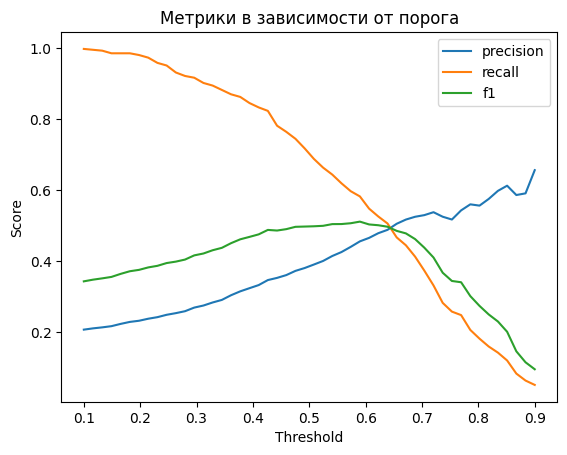

In [ ]:
plt.figure()

plt.plot(thr_df['threshold'], thr_df['precision'], label='precision')
plt.plot(thr_df['threshold'], thr_df['recall'], label='recall')
plt.plot(thr_df['threshold'], thr_df['f1'], label='f1')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Метрики в зависимости от порога')
plt.legend()

plt.show()

In [ ]:
best_thr = thr_df.sort_values(by='f1', ascending=False).iloc[0]
best_thr

,30
threshold,0.589796
precision,0.455769
recall,0.582310
f1,0.511327


В ходе анализа зависимости метрик качества от значения порога классификации было установлено, что значение по умолчанию (0.5) не является оптимальным.

Наилучшее значение F1-метрики достигается при пороге около 0.59, при котором наблюдается более сбалансированное соотношение precision и recall.

При увеличении порога модель становится более консервативной, что приводит к росту precision и снижению recall. Выбор порога позволяет адаптировать поведение модели в зависимости от требований бизнес-задачи.

## 4. Общий вывод

В результате проекта была построена интерпретируемая модель логистической регрессии, позволяющая эффективно прогнозировать отток клиентов и выявлять ключевые факторы риска. Проведённый анализ показал, что качество модели определяется не только алгоритмом, но и настройкой порога классификации, что делает модель гибким инструментом для решения прикладных задач.